<a href="https://colab.research.google.com/github/yosetcruz/Servicio-Social/blob/main/Dimuon_DoubleMu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path='Dimuon_DoubleMu.csv'
df = pd.read_csv(file_path, delimiter=',', header=0, encoding='latin1')

In [ ]:
variables = ['pt1', 'pt2', 'eta1', 'eta2', 'phi1', 'phi2']

df_plot = df[variables].apply(pd.to_numeric, errors='coerce')


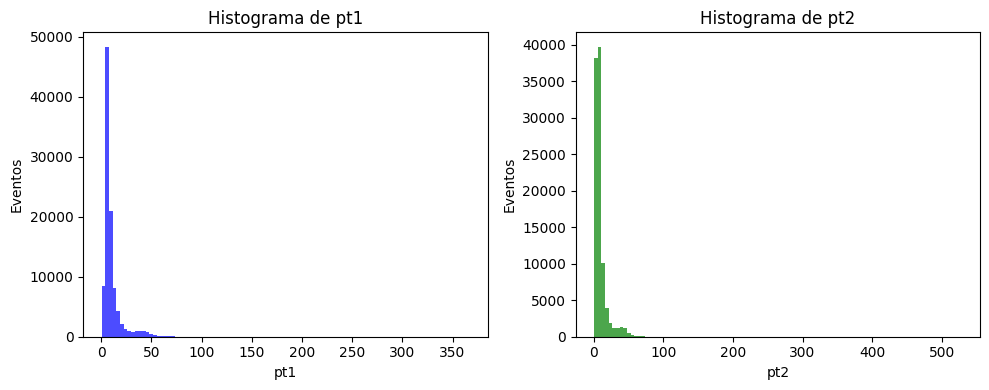

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df_plot['pt1'].dropna(), bins=100, color='blue', alpha=0.7)
plt.xlabel('pt1')
plt.ylabel('Eventos')
plt.title('Histograma de pt1')

plt.subplot(1, 2, 2)
plt.hist(df_plot['pt2'].dropna(), bins=100, color='green', alpha=0.7)
plt.xlabel('pt2')
plt.ylabel('Eventos')
plt.title('Histograma de pt2')

plt.tight_layout()
plt.show()



Este paso establece el número total de eventos disponibles antes de aplicar cualquier criterio de selección, funcionando como punto de referencia para cuantificar cuántos eventos se conservan o se descartan en cada corte y para calcular la eficiencia del proceso de selección.

In [ ]:
flow = {}
flow['Sin cortes'] = len(df)

In [ ]:
cut_pt = df[(df['pt1'] > 20) &
 (df['pt2'] > 20)]

flow['pT > 20 GeV'] = len(cut_pt)


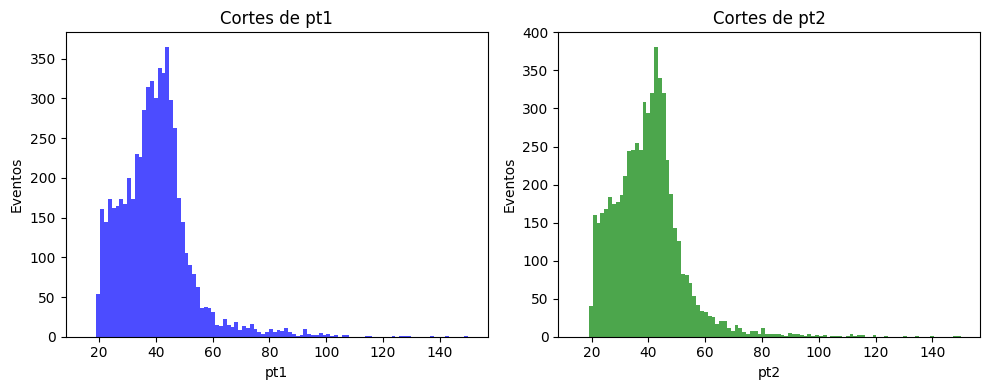

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(cut_pt['pt1'].dropna(), bins=100, range=(15,150), color='blue', alpha=0.7)
plt.xlabel('pt1')
plt.ylabel('Eventos')
plt.title('Cortes de pt1')

plt.subplot(1, 2, 2)
plt.hist(cut_pt['pt2'].dropna(), bins=100, range=(15,150), color='green', alpha=0.7)
plt.xlabel('pt2')
plt.ylabel('Eventos')
plt.title('Cortes de pt2')

plt.tight_layout()
plt.show()


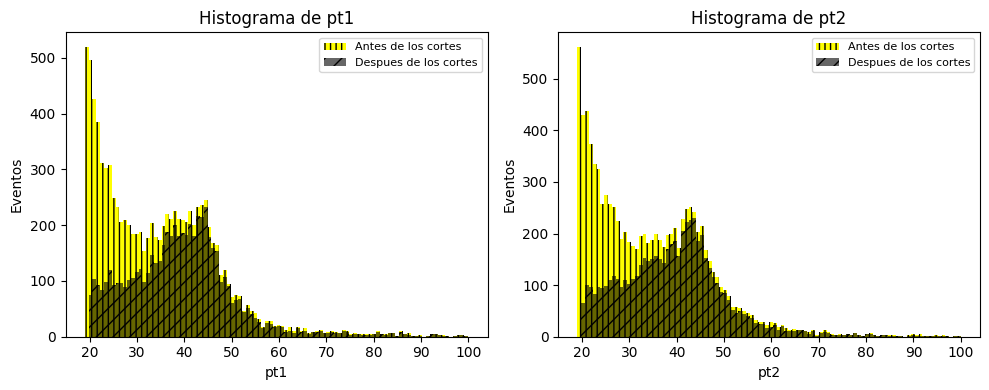

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title('Histograma de pt1')
rango_pt1 = (19, 100)
plt.hist(df_plot['pt1'].dropna(), bins=100,color='yellow', hatch = '|||', range = rango_pt1, label= 'Antes de los cortes')
plt.hist(cut_pt['pt1'].dropna(), bins=100, color='black',hatch = '//',  alpha=(0.6), range=rango_pt1, label= 'Despues de los cortes')
plt.xlabel('pt1')
plt.ylabel('Eventos')
plt.legend(fontsize=8)

plt.subplot(1, 2, 2)
plt.title('Histograma de pt2')
rango_pt2 = (19, 100)
plt.hist(df_plot['pt2'].dropna(), bins=100,color='yellow', hatch = '|||',range=rango_pt2, label= 'Antes de los cortes')
plt.hist(cut_pt['pt2'].dropna(), bins=100, color='black',hatch = '//',  alpha=(0.6), range=rango_pt2, label= 'Despues de los cortes')
plt.xlabel('pt2')
plt.ylabel('Eventos')
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

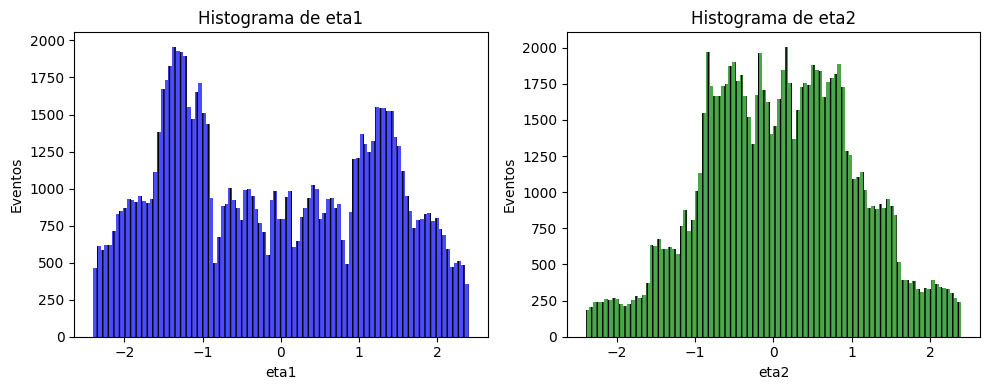

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df_plot['eta1'].dropna(), bins=100, hatch= '|||', color='blue', alpha=0.7)
plt.xlabel('eta1')
plt.ylabel('Eventos')
plt.title('Histograma de eta1')

plt.subplot(1, 2, 2)
plt.hist(df_plot['eta2'].dropna(), bins=100,hatch= '|||', color='green', alpha=0.7)
plt.xlabel('eta2')
plt.ylabel('Eventos')
plt.title('Histograma de eta2')

plt.tight_layout()
plt.show()

In [ ]:
cut_eta1 = df[np.abs(df['eta1']) < 2.1]
cut_eta2 = df[np.abs(df['eta2']) < 2.1]

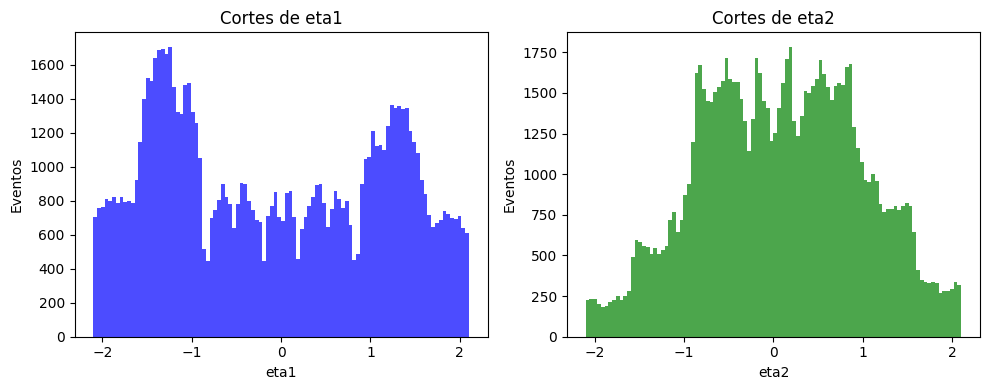

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(cut_eta1['eta1'].dropna(), bins=100, color='blue', alpha=0.7)
plt.xlabel('eta1')
plt.ylabel('Eventos')
plt.title('Cortes de eta1')

plt.subplot(1, 2, 2)
plt.hist(cut_eta2['eta2'].dropna(), bins=100, color='green', alpha=0.7)
plt.xlabel('eta2')
plt.ylabel('Eventos')
plt.title('Cortes de eta2')

plt.tight_layout()
plt.show()

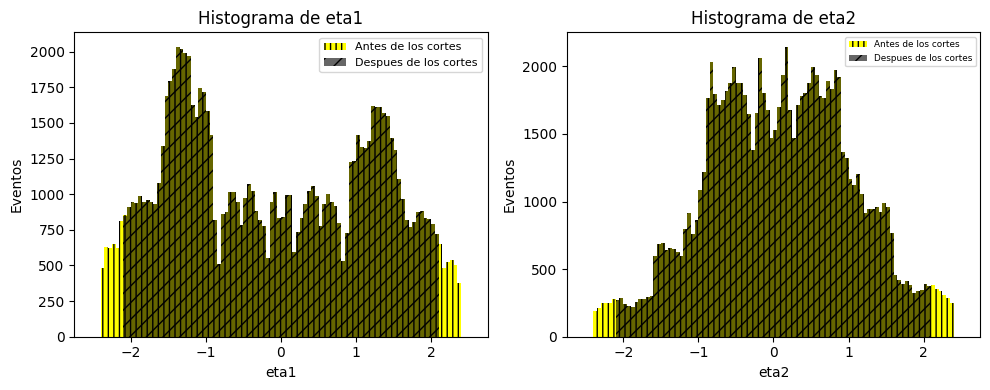

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title('Histograma de eta1')
rango_eta1=(-2.5,2.5)
plt.hist(df_plot['eta1'].dropna(), bins=100,color='yellow', hatch = '|||', range = rango_eta1, label= 'Antes de los cortes')
plt.hist(cut_eta1['eta1'].dropna(), bins=100, color='black',hatch = '//',  alpha=(0.6), range=rango_eta1, label= 'Despues de los cortes')
plt.xlabel('eta1')
plt.ylabel('Eventos')
plt.legend(fontsize=8)



plt.subplot(1, 2, 2)
plt.title('Histograma de eta2')
rango_eta2=(-2.5,2.5)
plt.hist(df_plot['eta2'].dropna(), bins=100,color='yellow', hatch = '|||', range = rango_eta2, label= 'Antes de los cortes')
plt.hist(cut_eta2['eta2'].dropna(), bins=100, color='black',hatch = '//',  alpha=(0.6), range=rango_eta2, label= 'Despues de los cortes')
plt.xlabel('eta2')
plt.ylabel('Eventos')
plt.legend(fontsize=6.4)


plt.tight_layout()
plt.show()

De todos los eventos que ya pasaron los filtros anteriores, solo se queda con aquellos donde los dos muones tienen cargas opuestas.

In [ ]:
cut_charge = cut_eta[cut_eta['Q1'] + cut_eta['Q2'] == 0]

flow['Cargas opuestas'] = len(cut_charge)


Selecciona únicamente los eventos donde ambos muones fueron detectados con la mejor calidad disponible, asegurando que la medición de la masa sea más precisa. Además, registra cuántos eventos cumplen esta condición dentro del flujo de cortes.

In [ ]:
cut_type = cut_charge[
    (cut_charge['type1'] == 'G') &
    (cut_charge['type2'] == 'G')]

flow['Global–Global'] = len(cut_type)


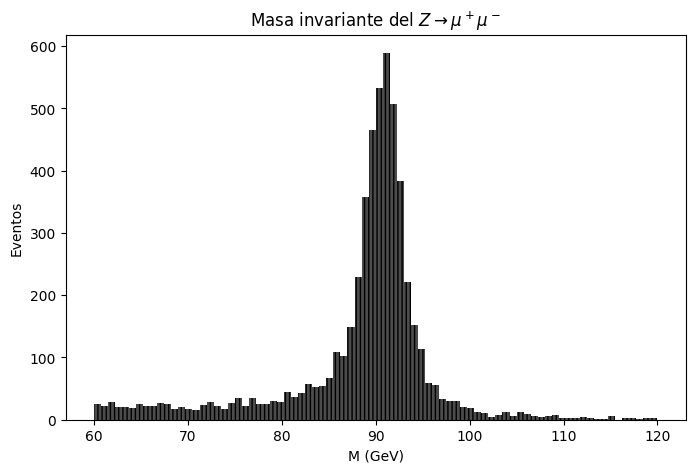

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(cut_type['M'].dropna(), bins=80, range=(60,120), hatch= '||||', color='black', alpha=0.7)
plt.xlabel('M (GeV)')
plt.ylabel('Eventos')
plt.title(r'Masa invariante del $Z \to \mu^+\mu^-$')
plt.show()


In [ ]:
cutflow = pd.DataFrame.from_dict(
    flow, orient='index', columns=['Eventos'])

cutflow['Eficiencia (%)'] = 100 * cutflow['Eventos'] / cutflow.iloc[0,0]

print(cutflow)


                 Eventos  Eficiencia (%)
Sin cortes        100000         100.000
pT > 20 GeV         5917           5.917
|eta| < 2.1        96636          96.636
|eta1,2| < 2.1     90944          90.944
Cargas opuestas    90944          90.944
Global–Global      86137          86.137


aplicación

Hola
¿En qué variable quieres aplicar el corte? (pt1, pt2, eta1, eta2): eta2
¿A partir de qué valor quieres hacer el corte?: 2.1

Corte aplicado en eta2
Eventos después del corte: 96636


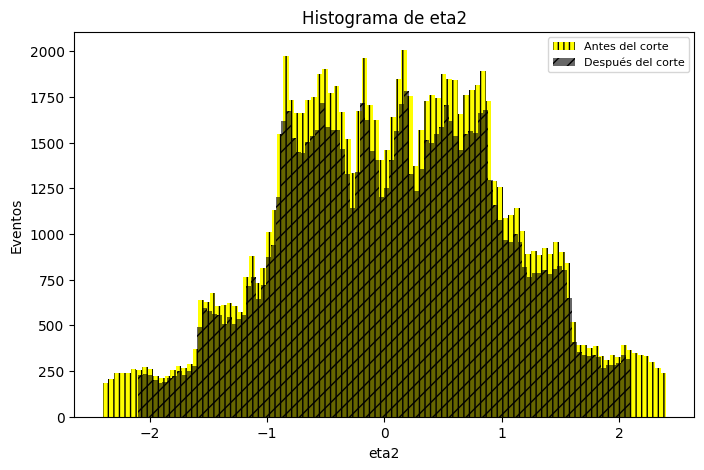

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("Hola")

variable=input("¿En qué variable quieres aplicar el corte? (pt1, pt2, eta1, eta2): ")
valor = float(input("¿A partir de qué valor quieres hacer el corte?: "))

variables_validas = ["pt1", "pt2", "eta1", "eta2"]

if variable not in variables_validas:
    print("Variable no válida")
else:
    if "pt" in variable:
        cut = df[df[variable] > valor]
    else:
        cut = df[np.abs(df[variable]) < valor]

    print(f"\nCorte aplicado en {variable}")
    print("Eventos después del corte:", len(cut))

    plt.figure(figsize=(8, 5))
    plt.title(f'Histograma de {variable}')

    plt.hist(df[variable].dropna(),
             bins=100,
             color='yellow',
             hatch='|||',
             label='Antes del corte')

    plt.hist(cut[variable].dropna(),
             bins=100,
             color='black',
             hatch='//',
             alpha=0.6,
             label='Después del corte')

    plt.xlabel(variable)
    plt.ylabel('Eventos')
    plt.legend(fontsize=8)
    plt.show()
